#**Simple Linear Regression – Marketing ROI**

**Project Overview**

In this project, you will analyze a marketing dataset using Python and statsmodels to build a Simple Linear Regression model. You will learn how to prepare data, select predictive variables, implement OLS regression, validate model assumptions, and interpret statistical outputs to drive business decisions. This project helps you understand how data science translates raw data into actionable marketing insights.

### Importing Necessary Libraries

In [11]:
%matplotlib inline
import pandas as pd

### Loading the marketing data into a `DataFrame`

In [12]:
# Import Data Files from Google Drive


import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/10hWl9J084H7sx8LVJ1zzb47B0f9FdxGG/view?usp=sharing"
gdd = read_gd(url)

df = pd.read_csv(gdd)

In [7]:
df.head(-5)

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4562,54.0,26.077597,3.808179,188.723202
4563,93.0,25.285149,2.805840,327.466288
4564,99.0,36.024174,4.288755,355.807121
4565,19.0,1.490192,1.485684,66.393800


## Exploratory Data Analysis (EDA)

### Data Overview

In [14]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


### Distribution of Features

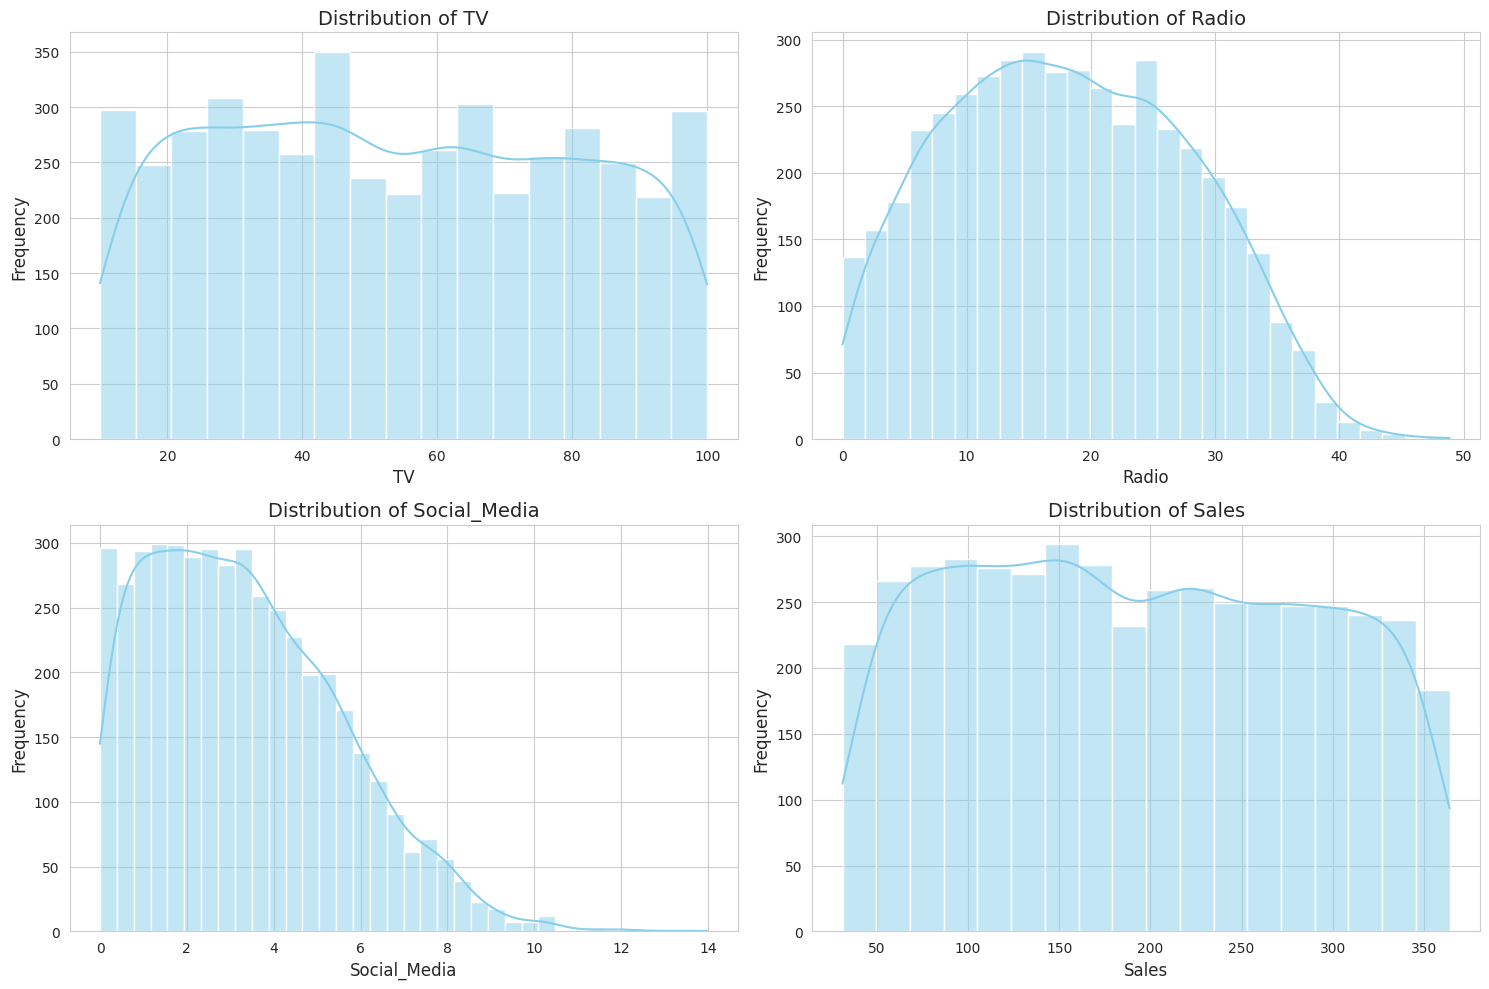

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style('whitegrid')

# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

# Plot histogram and KDE for each numerical column
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

### Relationship between Advertising Channels and Sales

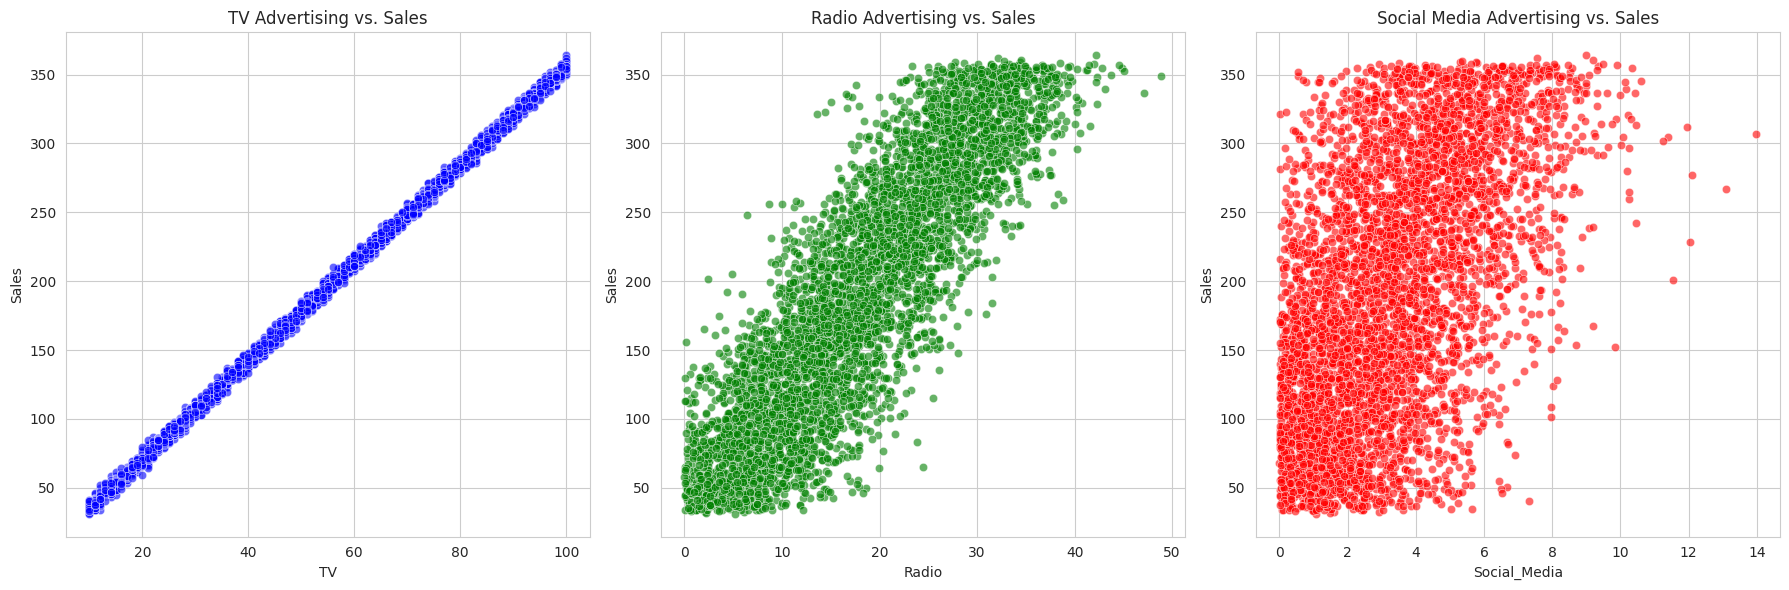

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.scatterplot(x='TV', y='Sales', data=df, ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('TV Advertising vs. Sales')

sns.scatterplot(x='Radio', y='Sales', data=df, ax=axes[1], color='green', alpha=0.6)
axes[1].set_title('Radio Advertising vs. Sales')

sns.scatterplot(x='Social_Media', y='Sales', data=df, ax=axes[2], color='red', alpha=0.6)
axes[2].set_title('Social Media Advertising vs. Sales')

plt.tight_layout()
plt.show()

### Correlation Matrix

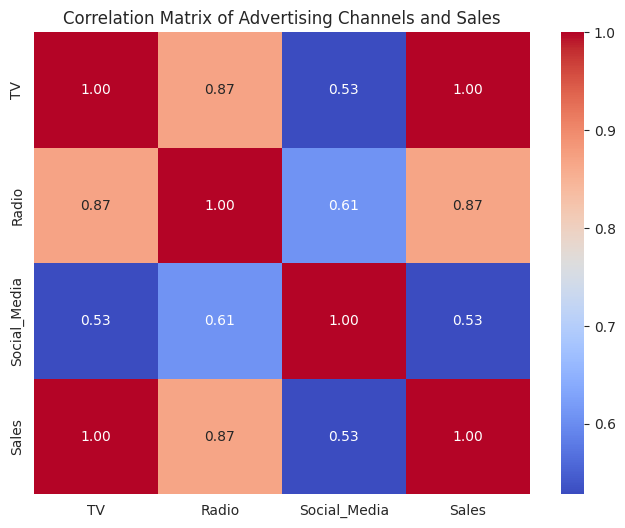

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Advertising Channels and Sales')
plt.show()

## Handling Missing Values

In [18]:
# Check for missing values before imputation
print("Missing values before imputation:")
display(df.isnull().sum())

# Impute missing values with the mean of each column
for column in df.columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mean())

# Check for missing values after imputation
print("\nMissing values after imputation:")
display(df.isnull().sum())

Missing values before imputation:


,0
TV,10
Radio,4
Social_Media,6
Sales,6



Missing values after imputation:


,0
TV,0
Radio,0
Social_Media,0
Sales,0


## Building an OLS Regression Model with `statsmodels`

In [21]:
import statsmodels.formula.api as smf

# Define the regression formula
# Sales is the dependent variable, TV, Radio, and Social_Media are independent variables
model_formula = 'Sales ~ TV + Radio + Social_Media'

# Create and fit the OLS model
ols_model = smf.ols(formula=model_formula, data=df).fit()

# Print the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 2.279e+05
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:53:59   Log-Likelihood:                -15749.
No. Observations:                4572   AIC:                         3.151e+04
Df Residuals:                    4568   BIC:                         3.153e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1372      0.264      0.520   

## Diagnostic Plots for OLS Regression

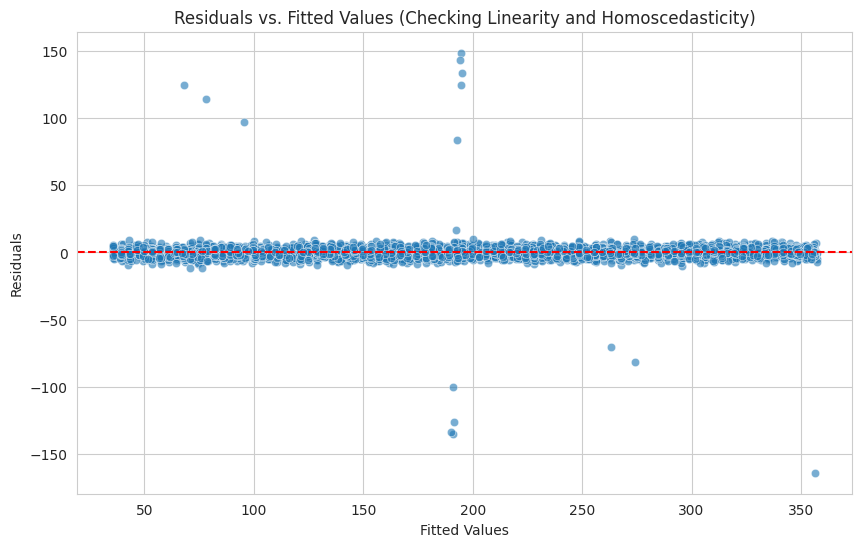

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals and fitted values from the OLS model
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (Checking Linearity and Homoscedasticity)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

### Normality of Residuals (Q-Q Plot)

<Figure size 800x800 with 0 Axes>

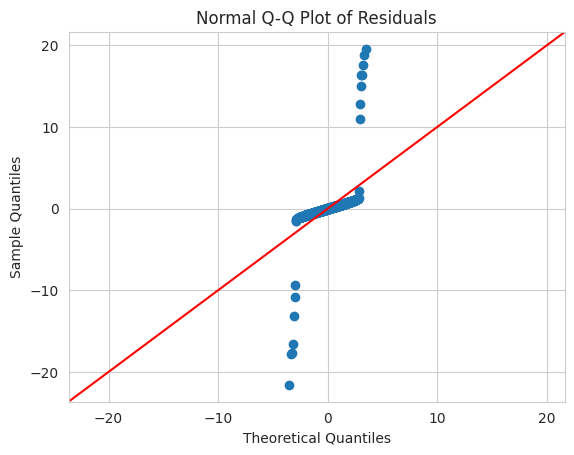

In [23]:
fig = plt.figure(figsize=(8, 8))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normal Q-Q Plot of Residuals')
plt.show()

### Normality of Residuals (Histogram)

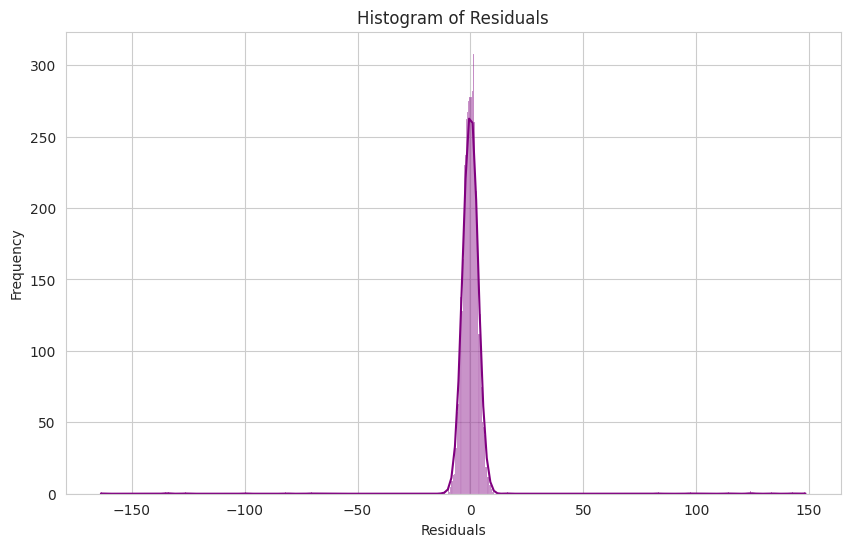

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#Interpreting R-squared, coefficients, and p-values in business context

**R-squared (0.993): Business Impact**

An R-squared of 0.993 is exceptionally high, indicating that approximately 99.3% of the variation in Sales can be explained by the spending on TV, Radio, and Social Media advertising.

From a business perspective, this is fantastic! It suggests that our advertising efforts are highly effective in driving sales, and we have a very good understanding of how these efforts translate into revenue. It implies that these three channels are the dominant factors influencing sales, and there's very little 'unexplained' variability.

Coefficients: Understanding the Impact of Each Channel

**TV (Coefficient: 3.5124):** This is a highly significant and impactful coefficient. In a business context, it means that for every additional dollar (or unit) spent on TV advertising, Sales are predicted to increase by approximately $3.51.  

This suggests that TV advertising is a very efficient and powerful channel for generating sales, providing a substantial return on investment.

**Radio (Coefficient: 0.1234):** This coefficient is also statistically significant, though smaller than TV's. It implies that for every additional dollar (or unit) spent on Radio advertising, Sales are predicted to increase by approximately $0.12. While not as high as TV, it still indicates a positive and measurable impact on sales, suggesting that radio advertising contributes to the overall sales performance.

**Social_Media (Coefficient: 0.0554, not statistically significant):** The positive coefficient suggests a potential increase in sales, but its lack of statistical significance (p-value of 0.385, much greater than 0.05) is crucial. In a business context, this means that, given the presence of TV and Radio advertising, we cannot confidently say that Social Media advertising has a statistically significant, independent impact on Sales. While it might contribute, its effect is too small or too noisy to be distinguished from zero within this model. This doesn't necessarily mean social media is ineffective overall, but rather that its direct and independent contribution to sales, when TV and Radio are also active, isn't clear from this model. It might be contributing in conjunction with other channels, or its impact might be harder to quantify directly with this linear model.

P-values: Confidence in Our Decisions

TV and Radio (p-values: 0.000): The extremely low p-values for TV and Radio advertising mean that there's a virtually zero chance that their observed positive impact on sales is due to random chance. This gives us high confidence in allocating resources to these channels and expecting a positive return.
Social_Media (p-value: 0.385): The high p-value for Social Media advertising indicates that there's a 38.5% chance that the observed positive effect is just random noise. This means we cannot be confident that increased spending on Social Media alone will directly lead to a statistically significant increase in sales, if TV and Radio are already present. From a business decision-making standpoint, this suggests that simply increasing social media spend might not yield the expected direct sales lift, and a more nuanced strategy or further investigation might be needed for this channel.

Overall Business Implications:

**Prioritize TV and Radio:** The model strongly suggests that TV and Radio are highly effective advertising channels for driving sales. Businesses should consider maintaining or even increasing investment in these areas where appropriate.

**Re-evaluate Social Media Strategy:** The current model doesn't show a statistically significant direct impact from Social Media. This doesn't mean abandoning it, but rather investigating its role further.

**High Predictability:** The very high R-squared means that sales are highly predictable based on advertising spend, allowing for better forecasting and budget allocation for TV and Radio.

## ROI-Based Marketing Budget Allocation Recommendation

### ROI-Based Recommendation for Marketing Budget Allocation:

1.  **Prioritize and Maximize Investment in TV Advertising:**
    *   **Rationale:** TV advertising demonstrates the highest and most significant ROI. Every dollar spent yields the largest direct return in sales. This is your most efficient and impactful channel.
    *   **Action:** Continue to allocate a substantial portion of the marketing budget to TV. Explore opportunities to optimize TV campaigns for even greater reach and impact, given its proven effectiveness.

2.  **Maintain and Strategically Optimize Radio Advertising:**
    *   **Rationale:** Radio advertising also shows a statistically significant positive return on investment, although lower than TV. It's a contributing factor to sales.
    *   **Action:** Continue investing in Radio advertising. Consider optimizing ad placements, messaging, and target audiences to potentially enhance its ROI. It might serve as a valuable complementary channel to TV, reinforcing brand message and reaching different segments.

3.  **Re-evaluate and Investigate Social Media Strategy (Beyond Direct Sales ROI):**
    *   **Rationale:** The model could not confirm a *statistically significant direct sales impact* from Social Media advertising when TV and Radio are present. This doesn't mean it's useless, but its direct sales ROI in this model is unclear.
    *   **Action:** Instead of simply increasing budget for direct sales, conduct targeted experiments with Social Media. Explore its role in brand awareness, customer engagement, lead generation (not directly sales), or supporting other channels. Measure these alternative metrics. If a direct sales impact is desired, consider different campaign types, audience targeting, or even non-linear models that might better capture its influence. Avoid significant increases in budget solely for direct sales based on the current model's findings.

**Overall Strategic Guideline:**

Focus on leveraging the channels with proven, high ROI (TV and Radio) for direct sales generation. For channels with less clear direct impact (Social Media), shift focus to understanding their indirect contributions, optimizing for non-sales objectives, or conducting more precise experiments to isolate their true value.